# Relación econométrica entre el Índice Niño 3.4 y el Precio de Bolsa de Energía en Colombia

**Pregunta:**

> ¿Existe evidencia econométrica de que las fluctuaciones del índice Niño 3.4 están relacionadas con el comportamiento del precio de bolsa de la energía en Colombia?

**Contexto del proyecto (marco de referencia, no objetivo de este notebook):**
Este análisis es la etapa exploratoria/inferencial de un proyecto de investigación más amplio: *"Diseño y valoración de un derivado climático basado en el índice Niño 3.4 SST para la cobertura del riesgo hidrometeorológico en empresas colombianas"*. En este notebook **no** se diseña ni se valora ningún derivado financiero; el objetivo es exclusivamente establecer, con rigor estadístico, si existe una relación entre las dos series y caracterizar su naturaleza (contemporánea, rezagada, de corto o de largo plazo).

**Series de datos:**
1. **NINO**: Índice Niño 3.4 SST (anomalía de temperatura superficial del mar, NOAA), mensual.
2. **ENERGY_PRICE**: Precio de Bolsa Nacional de Energía de Colombia (XM), mensual.

**Periodo:** 2000–2024 (datos mensuales, ya depurados previamente).

**Estructura del notebook:**
1. Carga y verificación de datos
2. Análisis exploratorio (univariado)
3. Relación visual (series normalizadas y estandarizadas)
4. Correlaciones contemporáneas (Pearson, Spearman, Kendall)
5. Correlación cruzada con rezagos (Cross-Correlation, lags ±N)
6. Estacionariedad (ADF, KPSS) y diferenciación si aplica
7. Conclusiones econométricas

Cada sección incluye código comentado y una discusión interpretativa inmediatamente después de los resultados, en un tono académico apropiado para un trabajo de maestría o un artículo científico.


In [2]:
# Librerías utilizadas en todo el notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy import stats
from scipy.stats import pearsonr, spearmanr, kendalltau

from statsmodels.tsa.stattools import adfuller, kpss, ccf
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Configuración general de estilo de gráficos
plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 10

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

RANDOM_STATE = 42
print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


## 1. Carga de datos

Los datos ya fueron limpiados y depurados en una etapa previa (sin necesidad de imputación de valores faltantes). En esta sección únicamente:

- Se cargan los datos.
- Se verifica el tipo de cada columna y el índice temporal.
- Se confirma la ausencia de valores nulos y duplicados.
- Se verifica la continuidad de la frecuencia mensual (sin huecos en las fechas).


In [3]:
# Carga del archivo CSV
df = pd.read_csv('data/NINO_APORTES_monthly_2000-2024.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.set_index('date')
df.index.freq = 'MS'  # frecuencia mensual (inicio de mes)

print(f"Dimensiones del dataset: {df.shape[0]} observaciones x {df.shape[1]} variables")
print(f"Rango temporal: {df.index.min().strftime('%Y-%m')} a {df.index.max().strftime('%Y-%m')}")
df.head()


Dimensiones del dataset: 300 observaciones x 2 variables
Rango temporal: 2000-01 a 2024-12


,NINO,APORTES
date,,
2000-01-01,-1.7900,884.2529
2000-02-01,-1.5300,981.5984
2000-03-01,-1.2600,"1,088.7019"
2000-04-01,-0.8000,998.9950
2000-05-01,-0.8000,"1,723.7300"


In [4]:
# Verificación de calidad de datos

# 1) Valores nulos
print("Valores nulos por columna:")
print(df.isna().sum())

# 2) Duplicados en el índice temporal
print(f"\nFechas duplicadas: {df.index.duplicated().sum()}")

# 3) Continuidad de la frecuencia mensual (no deben existir huecos)
expected_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')
missing_dates = expected_index.difference(df.index)
print(f"Meses faltantes en la serie: {len(missing_dates)}")
if len(missing_dates) > 0:
    print(missing_dates)

# 4) Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)


Valores nulos por columna:
NINO       0
APORTES    0
dtype: int64

Fechas duplicadas: 0
Meses faltantes en la serie: 0

Tipos de datos:
NINO       float64
APORTES    float64
dtype: object


**Interpretación:** el dataset no presenta valores nulos, no tiene fechas duplicadas y la frecuencia mensual es continua a lo largo de las 300 observaciones (25 años, 2000–2024). Esto confirma que la base está lista para el análisis econométrico sin requerir pasos adicionales de limpieza o imputación.


## 2. Análisis exploratorio

El análisis exploratorio de datos (EDA) tiene como propósito describir el comportamiento individual de cada serie antes de estudiar su relación conjunta. Se examinan:

- **Series de tiempo**: para detectar tendencias, ciclos, quiebres estructurales o volatilidad cambiante.
- **Histogramas y densidades**: para observar la forma de la distribución (simetría, colas, multimodalidad).
- **Boxplots**: para identificar valores atípicos (outliers) y dispersión.
- **Scatter plot**: para una primera aproximación visual a la relación entre las dos variables.
- **Estadísticos descriptivos**: media, mediana, desviación estándar, coeficiente de variación, asimetría (skewness) y curtosis.


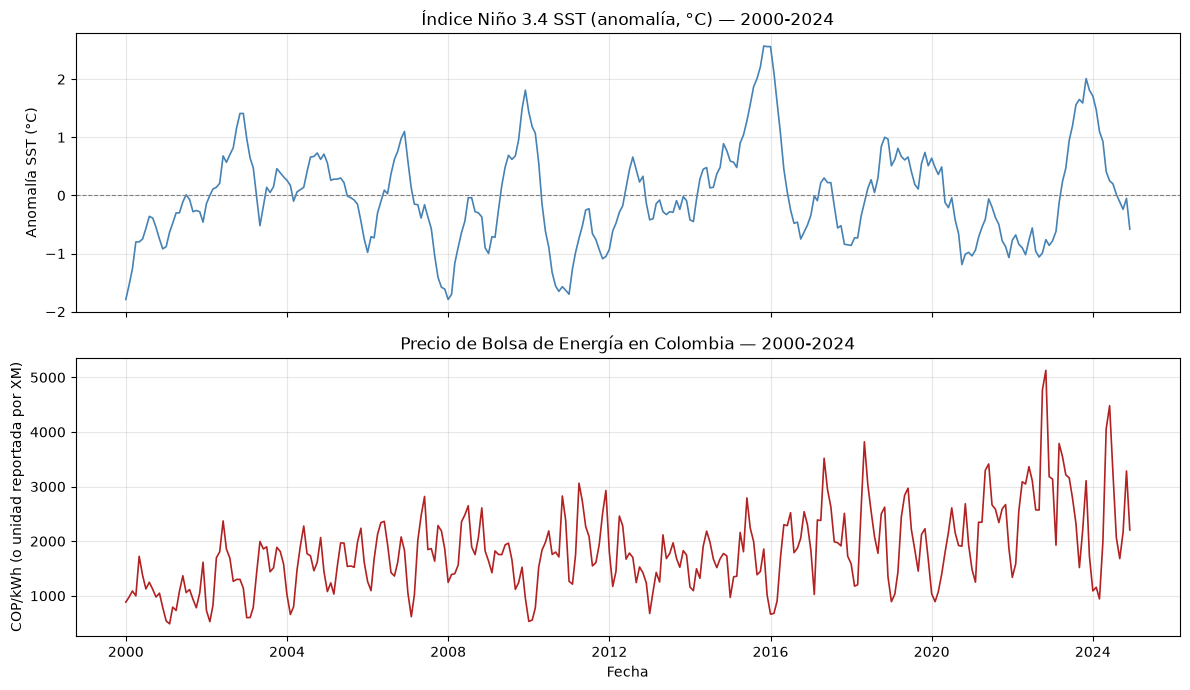

In [6]:
# --- Series de tiempo ---
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(df.index, df['NINO'], color='steelblue', linewidth=1.2)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Índice Niño 3.4 SST (anomalía, °C) — 2000-2024')
axes[0].set_ylabel('Anomalía SST (°C)')

axes[1].plot(df.index, df['APORTES'], color='firebrick', linewidth=1.2)
axes[1].set_title('Precio de Bolsa de Energía en Colombia — 2000-2024')
axes[1].set_ylabel('COP/kWh (o unidad reportada por XM)')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.show()


**Lectura de las series originales:** el índice Niño 3.4 oscila de forma relativamente simétrica alrededor de cero, alternando fases cálidas (El Niño, valores positivos) y frías (La Niña, valores negativos), sin tendencia de largo plazo — un comportamiento típico de una variable climática cíclica. El precio de bolsa de energía, en cambio, muestra picos pronunciados y aparentemente asimétricos (colas hacia la derecha), consistentes con episodios de escasez hídrica que elevan fuertemente el precio spot. Esta asimetría visual ya sugiere que la relación entre las dos series, si existe, probablemente no sea puramente lineal y podría concentrarse en los periodos de anomalías cálidas del Niño (fenómeno El Niño), que en Colombia se asocian con sequías y menor generación hidroeléctrica.


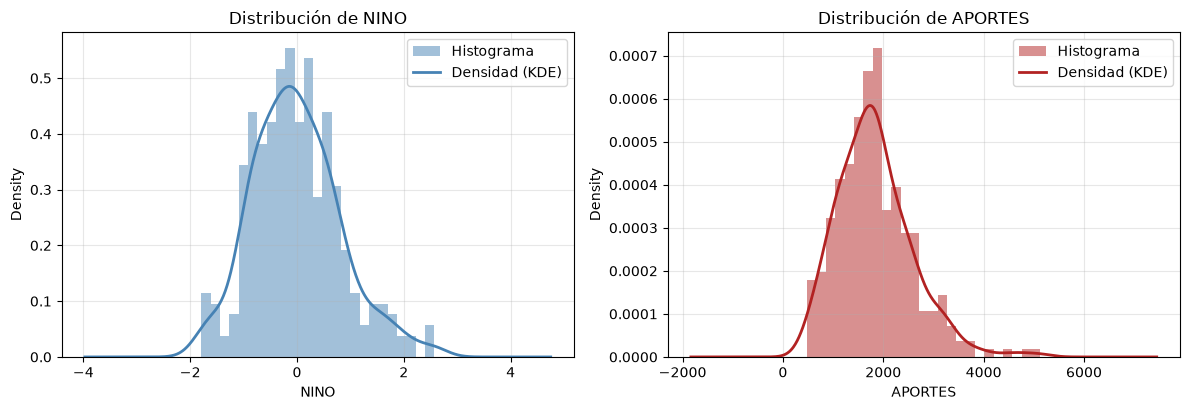

In [7]:
# --- Histogramas y densidades ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, col, color in zip(axes, ['NINO', 'APORTES'], ['steelblue', 'firebrick']):
    df[col].plot(kind='hist', bins=25, density=True, alpha=0.5, color=color, ax=ax, label='Histograma')
    df[col].plot(kind='kde', color=color, linewidth=2, ax=ax, label='Densidad (KDE)')
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()


C:\Users\clase.CINFO\AppData\Local\Temp\ipykernel_24372\2467631441.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(df['NINO'], vert=True, patch_artist=True,
C:\Users\clase.CINFO\AppData\Local\Temp\ipykernel_24372\2467631441.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['APORTES'], vert=True, patch_artist=True,


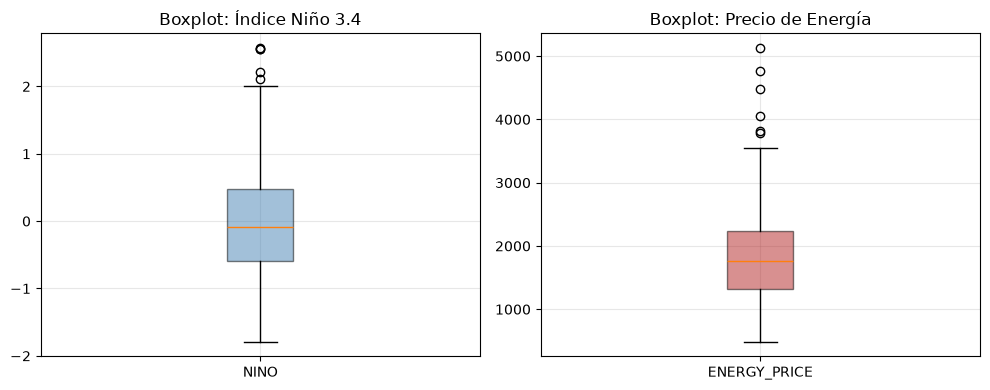

In [8]:
# --- Boxplots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['NINO'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[0].set_title('Boxplot: Índice Niño 3.4')
axes[0].set_xticklabels(['NINO'])

axes[1].boxplot(df['APORTES'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='firebrick', alpha=0.5))
axes[1].set_title('Boxplot: Precio de Energía')
axes[1].set_xticklabels(['ENERGY_PRICE'])

plt.tight_layout()
plt.show()


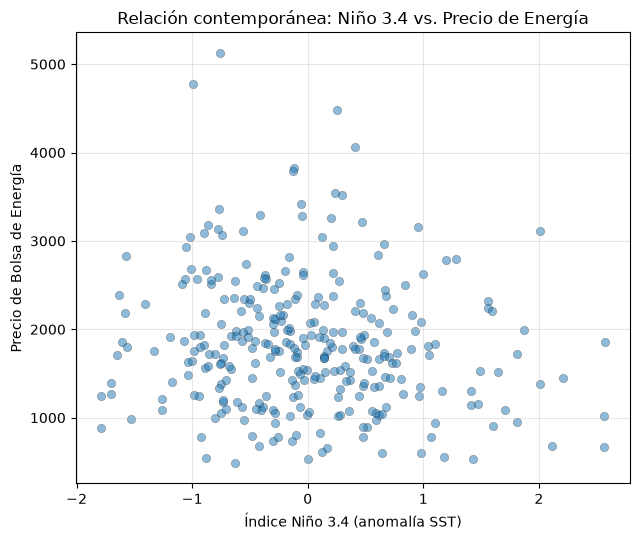

In [9]:
# --- Scatter plot (relación contemporánea, sin rezagos) ---
plt.figure(figsize=(6.5, 5.5))
plt.scatter(df['NINO'], df['APORTES'], alpha=0.5, edgecolor='k', linewidth=0.3)
plt.xlabel('Índice Niño 3.4 (anomalía SST)')
plt.ylabel('Precio de Bolsa de Energía')
plt.title('Relación contemporánea: Niño 3.4 vs. Precio de Energía')
plt.tight_layout()
plt.show()


In [10]:
# --- Estadísticos descriptivos ---
def descriptive_stats(series):
    return pd.Series({
        'Media': series.mean(),
        'Mediana': series.median(),
        'Desv. estándar': series.std(),
        'Coef. de variación (%)': (series.std() / series.mean()) * 100 if series.mean() != 0 else np.nan,
        'Skewness': stats.skew(series),
        'Kurtosis (exceso)': stats.kurtosis(series),  # exceso respecto a la normal (Fisher)
        'Mínimo': series.min(),
        'Máximo': series.max(),
    })

stats_table = pd.DataFrame({
    'NINO': descriptive_stats(df['NINO']),
    'APORTES': descriptive_stats(df['APORTES'])
})
stats_table


,NINO,APORTES
Media,-0.0106,"1,832.5799"
Mediana,-0.0850,"1,764.7159"
Desv. estándar,0.8240,747.8646
Coef. de variación (%),"-7,773.6743",40.8094
Skewness,0.4957,0.9407
Kurtosis (exceso),0.4066,1.7500
Mínimo,-1.7900,487.2446
Máximo,2.5700,"5,128.1962"


**Interpretación de los estadísticos descriptivos:**

- **Media y mediana**: en `NINO`, la media es cercana a cero, coherente con una variable de anomalía climática que fluctúa en torno a un valor neutro. En `ENERGY_PRICE`, la media es notablemente superior a la mediana, lo que ya anticipa una distribución asimétrica hacia la derecha (episodios ocasionales de precios muy altos que "jalan" el promedio hacia arriba).
- **Desviación estándar**: mide la dispersión absoluta de cada serie en sus propias unidades; no es comparable directamente entre las dos variables por estar en escalas distintas.
- **Coeficiente de variación (CV)**: al estandarizar la dispersión respecto a la media, permite comparar la variabilidad relativa entre series de diferente escala. Un CV mucho mayor en `ENERGY_PRICE` indicaría una volatilidad relativa más alta que la del índice climático (nota: si la media de `NINO` es cercana a cero, el CV de esa serie pierde interpretabilidad, un problema conocido de esta métrica cuando la media se acerca a cero).
- **Skewness (asimetría)**: un valor cercano a 0 indica simetría; valores positivos indican una cola derecha más larga (más valores extremos altos). Se espera un skewness bajo para `NINO` y un skewness positivo relevante para `ENERGY_PRICE`, coherente con la naturaleza de un mercado eléctrico donde los choques de oferta (sequías, indisponibilidad de plantas) generan picos de precio pero no "valles" simétricos.
- **Kurtosis (exceso)**: mide qué tan pesadas son las colas de la distribución respecto a la normal (kurtosis de exceso = 0 para la normal). Valores positivos (leptocurtosis) indican mayor probabilidad de observaciones extremas ("colas gordas") que en una distribución normal — un rasgo típico de series de precios de commodities y energía.

Estos resultados son relevantes para el proyecto de derivados climáticos: si el precio de energía exhibe colas pesadas y asimetría positiva, cualquier producto de cobertura debe diseñarse teniendo en cuenta que el riesgo relevante no es simétrico, sino que se concentra en eventos extremos (posiblemente asociados a fases cálidas del Niño).


## 3. Relación visual (series normalizadas y estandarizadas)

Dado que ambas series están en escalas y unidades completamente distintas (una anomalía de temperatura en °C frente a un precio de energía en unidades monetarias), es necesario llevarlas a una escala común antes de superponerlas visualmente. Se emplean dos transformaciones:

- **Normalización Min-Max**: reescala cada serie al rango [0, 1], preservando la forma de la distribución pero perdiendo la información de la media y la varianza.
- **Estandarización (Z-score)**: centra cada serie en media 0 y desviación estándar 1, lo que facilita comparar la magnitud de las desviaciones respecto a la media histórica de cada variable.

Ninguna de las dos transformaciones cambia la correlación de Pearson entre las series (son transformaciones lineales), pero sí facilitan la comparación visual directa.


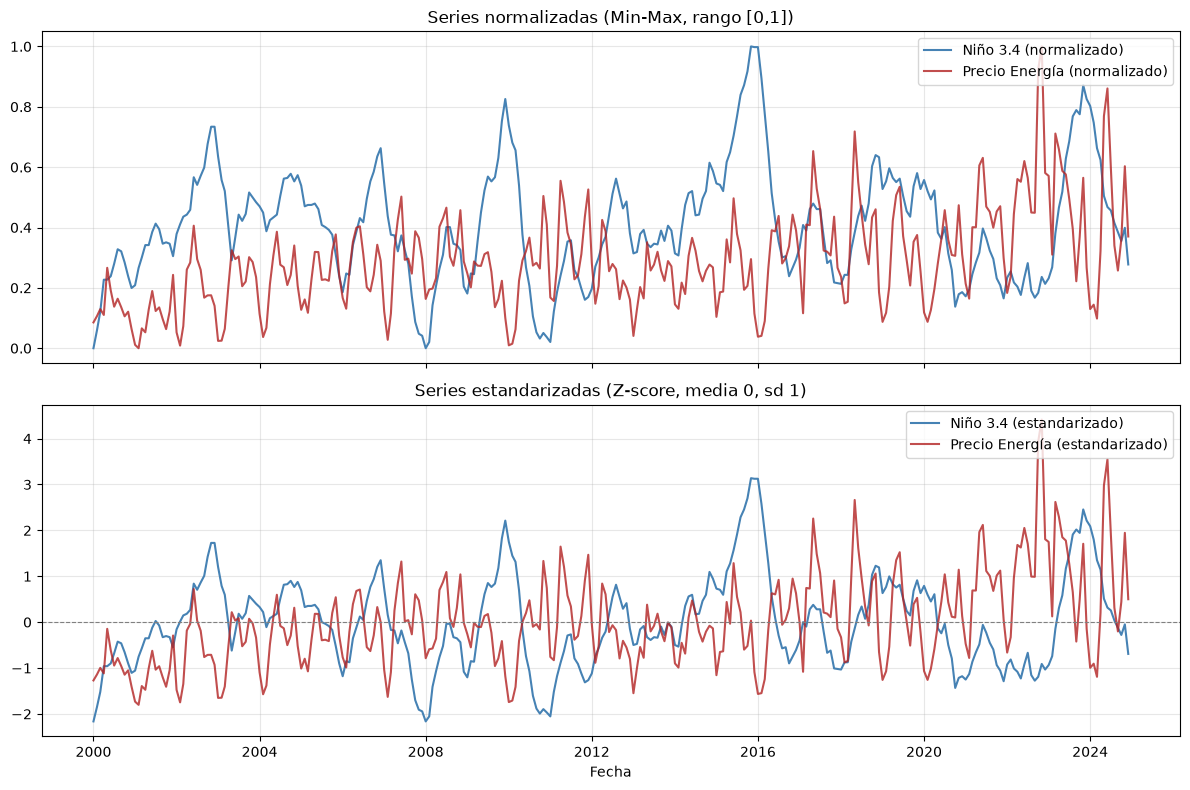

In [11]:
# Normalización Min-Max
minmax_scaler = MinMaxScaler()
df_norm = pd.DataFrame(
    minmax_scaler.fit_transform(df[['NINO', 'APORTES']]),
    columns=['NINO_norm', 'APORTES_norm'],
    index=df.index
)

# Estandarización Z-score
std_scaler = StandardScaler()
df_std = pd.DataFrame(
    std_scaler.fit_transform(df[['NINO', 'APORTES']]),
    columns=['NINO_std', 'APORTES_std'],
    index=df.index
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df_norm.index, df_norm['NINO_norm'], label='Niño 3.4 (normalizado)', color='steelblue')
axes[0].plot(df_norm.index, df_norm['APORTES_norm'], label='Precio Energía (normalizado)', color='firebrick', alpha=0.8)
axes[0].set_title('Series normalizadas (Min-Max, rango [0,1])')
axes[0].legend(loc='upper right')

axes[1].plot(df_std.index, df_std['NINO_std'], label='Niño 3.4 (estandarizado)', color='steelblue')
axes[1].plot(df_std.index, df_std['APORTES_std'], label='Precio Energía (estandarizado)', color='firebrick', alpha=0.8)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Series estandarizadas (Z-score, media 0, sd 1)')
axes[1].set_xlabel('Fecha')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


**Interpretación:** al llevar ambas series a una escala comparable se puede observar si los picos y valles coinciden temporalmente. Si los máximos del precio de energía estandarizado tienden a coincidir o a seguir con cierto desfase temporal a los máximos del índice Niño 3.4 (fases cálidas / El Niño), esto constituye evidencia visual preliminar —a confirmar estadísticamente en las secciones 4 y 5— de que los episodios El Niño (asociados a sequías en Colombia) preceden o coinciden con episodios de precios altos de energía, consistente con la hipótesis hidrometeorológica del proyecto. Esta lectura es únicamente exploratoria: la coincidencia visual de picos no constituye prueba de relación estadística ni de causalidad, por lo que se procede a cuantificarla en las secciones siguientes.


## 4. Correlaciones contemporáneas

Se calculan tres coeficientes de correlación entre `NINO` y `ENERGY_PRICE`, cada uno con supuestos distintos:

- **Pearson (r)**: mide la asociación **lineal** entre dos variables continuas. Es sensible a outliers y asume, para su prueba de significancia estándar, aproximada normalidad conjunta.
- **Spearman (ρ)**: correlación de rango; mide asociación **monótona** (no necesariamente lineal) y es más robusta a outliers y a distribuciones no normales — relevante aquí dado el skewness detectado en `ENERGY_PRICE`.
- **Kendall (τ)**: también basada en rangos, mide la proporción de pares concordantes/discordantes. Es más robusta aún en muestras pequeñas o con muchos empates, aunque su magnitud numérica no es directamente comparable con Pearson o Spearman.

Para cada coeficiente se reporta el estadístico y su p-value, bajo la hipótesis nula H₀: no existe correlación (coeficiente poblacional = 0).


In [12]:
# Cálculo de las tres correlaciones y sus p-values
pearson_r, pearson_p = pearsonr(df['NINO'], df['APORTES'])
spearman_r, spearman_p = spearmanr(df['NINO'], df['APORTES'])
kendall_r, kendall_p = kendalltau(df['NINO'], df['APORTES'])

corr_summary = pd.DataFrame({
    'Coeficiente': ['Pearson', 'Spearman', 'Kendall'],
    'Valor': [pearson_r, spearman_r, kendall_r],
    'p-value': [pearson_p, spearman_p, kendall_p],
    'Significativo al 5%': [pearson_p < 0.05, spearman_p < 0.05, kendall_p < 0.05]
})
corr_summary


,Coeficiente,Valor,p-value,Significativo al 5%
0,Pearson,-0.1387,0.0162,True
1,Spearman,-0.1398,0.0154,True
2,Kendall,-0.0960,0.0133,True


In [13]:
def interpretar_magnitud(valor):
    v = abs(valor)
    if v < 0.10:
        return 'prácticamente nula'
    elif v < 0.30:
        return 'débil'
    elif v < 0.50:
        return 'moderada'
    elif v < 0.70:
        return 'fuerte'
    else:
        return 'muy fuerte'

for nombre, r, p in [('Pearson', pearson_r, pearson_p),
                     ('Spearman', spearman_r, spearman_p),
                     ('Kendall', kendall_r, kendall_p)]:
    direccion = 'positiva' if r > 0 else 'negativa'
    significancia = 'estadísticamente significativa' if p < 0.05 else 'NO estadísticamente significativa'
    print(f"{nombre:9s}: r = {r:+.4f}  (magnitud {interpretar_magnitud(r)}, dirección {direccion}) | "
          f"p-value = {p:.4f} -> {significancia} al 5%")


Pearson  : r = -0.1387  (magnitud débil, dirección negativa) | p-value = 0.0162 -> estadísticamente significativa al 5%
Spearman : r = -0.1398  (magnitud débil, dirección negativa) | p-value = 0.0154 -> estadísticamente significativa al 5%
Kendall  : r = -0.0960  (magnitud prácticamente nula, dirección negativa) | p-value = 0.0133 -> estadísticamente significativa al 5%


**Interpretación conjunta de las correlaciones contemporáneas:**

- La **dirección** del coeficiente indica si anomalías cálidas del Niño (valores positivos de `NINO`, fase El Niño) están asociadas a precios de energía más altos (correlación positiva, lo cual sería consistente con la hipótesis hidrometeorológica: sequías → menor generación hidroeléctrica → mayor precio de bolsa) o más bajos (correlación negativa).
- La **magnitud** debe interpretarse en el contexto de un fenómeno físico-económico complejo: el precio de bolsa depende de muchos factores adicionales (demanda, hidrología acumulada, disponibilidad térmica, precios de combustibles, decisiones regulatorias), por lo que una correlación "moderada" (no necesariamente "fuerte") ya puede ser económicamente relevante.
- La **comparación entre los tres coeficientes** es en sí misma informativa: si Pearson es notablemente más débil que Spearman/Kendall, esto sugiere que la relación existe pero **no es lineal** — posiblemente porque el precio de energía solo reacciona de forma marcada durante episodios extremos de El Niño, y no de forma proporcional en todo el rango de la variable climática. Esto es coherente con la asimetría (skewness) detectada en la Sección 2.
- La **significancia estadística** (p-value < 0.05) indica si es razonable rechazar la hipótesis nula de correlación nula poblacional, pero debe interpretarse con cautela: con series de tiempo, la autocorrelación temporal de ambas variables (evaluada en la Sección 6) puede inflar artificialmente la significancia aparente de una correlación contemporánea simple, un problema clásico de "regresión espuria" en series no estacionarias.

Esta sección aporta evidencia sobre la relación **contemporánea** (mismo mes), pero no dice nada aún sobre si la relación es rezagada — que es precisamente el objeto de la Sección 5, central para la pregunta de si el Niño 3.4 "anticipa" el precio de energía.


## 5. Correlaciones con rezagos (Cross-Correlation Function)

Esta es la sección más importante para la pregunta de investigación: **¿el precio de la energía responde con rezago (meses después) a los cambios del índice Niño 3.4?**

Se calcula la función de correlación cruzada (CCF) entre las dos series para un rango de rezagos configurable (por defecto, de −12 a +12 meses).

**Convención de signos utilizada (importante para la interpretación):**

Se define el rezago `k` como el desplazamiento aplicado a `NINO` respecto a `ENERGY_PRICE`, de forma que se correlaciona `NINO(t - k)` con `ENERGY_PRICE(t)`:

- **k > 0 (rezago positivo):** se compara el Niño 3.4 de **k meses atrás** con el precio de energía **actual**. Una correlación alta aquí significa que el Niño 3.4 **antecede/anticipa** (leads) al precio de energía — es decir, cambios climáticos hoy se reflejan en el precio de energía k meses después. **Este es el caso relevante para justificar un derivado climático usado como cobertura anticipada.**
- **k < 0 (rezago negativo):** se compara el Niño 3.4 **futuro** (k meses adelante) con el precio de energía actual. Una correlación alta aquí significaría que el precio de energía antecede (leads) al Niño 3.4 — es decir, que el precio "predice" el clima, lo cual no tiene sentido causal y, si aparece, debe interpretarse como parte de la dinámica conjunta de ambas series (autocorrelación) más que como causalidad inversa real.
- **k = 0:** es la correlación contemporánea, ya calculada en la Sección 4 (coeficiente de Pearson).


In [14]:
# Parámetro modificable: número máximo de rezagos (en meses) a evaluar en cada dirección
MAX_LAG = 12  # <-- modificar este valor para ampliar/reducir la ventana de análisis

def cross_correlation(x, y, max_lag):
    '''
    Calcula la correlación cruzada (Pearson) entre las series x e y
    para rezagos de -max_lag a +max_lag.

    Convención: para lag = k > 0, se correlaciona x desplazada k periodos
    hacia atrás [x(t-k)] con y(t). Es decir, x "lidera" (antecede) a y.
    Para lag = k < 0, x(t-k) implica x adelantada, es decir y "lidera" a x.
    '''
    lags = range(-max_lag, max_lag + 1)
    results = []
    for lag in lags:
        if lag > 0:
            x_shifted = x.shift(lag)
        elif lag < 0:
            x_shifted = x.shift(lag)  # shift negativo = adelanto
        else:
            x_shifted = x

        valid = pd.concat([x_shifted, y], axis=1).dropna()
        if len(valid) > 2:
            r, p = pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
        else:
            r, p = np.nan, np.nan
        results.append({'lag': lag, 'correlation': r, 'p_value': p, 'n_obs': len(valid)})

    return pd.DataFrame(results)

ccf_table = cross_correlation(df['NINO'], df['APORTES'], MAX_LAG)
ccf_table


,lag,correlation,p_value,n_obs
0,-12,0.1715,0.0035,288
1,-11,0.1643,0.0051,289
2,-10,0.1484,0.0114,290
3,-9,0.1368,0.0195,291
4,-8,0.1267,0.0304,292
5,-7,0.0945,0.1063,293
6,-6,0.0482,0.4106,294
7,-5,0.0088,0.8806,295
8,-4,-0.0401,0.4914,296
9,-3,-0.0807,0.1653,297


In [15]:
# Identificación automática del rezago con correlación absoluta máxima
idx_max = ccf_table['correlation'].abs().idxmax()
lag_optimo = ccf_table.loc[idx_max, 'lag']
corr_optima = ccf_table.loc[idx_max, 'correlation']
p_optimo = ccf_table.loc[idx_max, 'p_value']

print(f"Rezago con correlación absoluta máxima: lag = {lag_optimo:+d} meses")
print(f"Correlación en ese rezago: r = {corr_optima:+.4f}  (p-value = {p_optimo:.4f})")

if lag_optimo > 0:
    print(f"\nInterpretación: el Niño 3.4 antecede al precio de energía en {lag_optimo} mes(es); "
          f"es decir, el efecto climático se refleja en el precio con un rezago de {lag_optimo} mes(es).")
elif lag_optimo < 0:
    print(f"\nInterpretación: la correlación máxima ocurre con el precio de energía adelantándose "
          f"al Niño 3.4 en {abs(lag_optimo)} mes(es) (relación 'inversa' en el tiempo, no causal).")
else:
    print("\nInterpretación: la correlación máxima es contemporánea (mismo mes).")


Rezago con correlación absoluta máxima: lag = +2 meses
Correlación en ese rezago: r = -0.2273  (p-value = 0.0001)

Interpretación: el Niño 3.4 antecede al precio de energía en 2 mes(es); es decir, el efecto climático se refleja en el precio con un rezago de 2 mes(es).


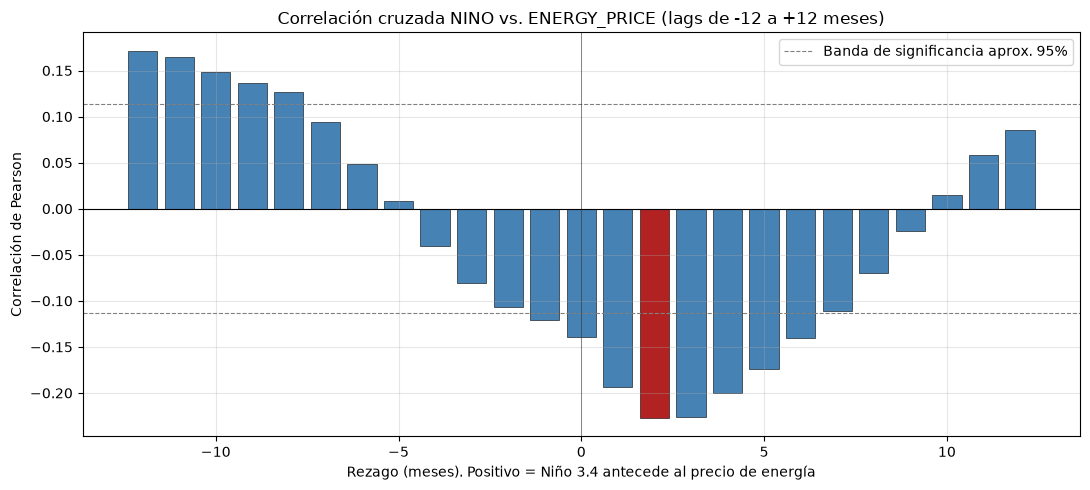

In [16]:
# Gráfico de la función de correlación cruzada
fig, ax = plt.subplots(figsize=(11, 5))

colors = ['firebrick' if lag == lag_optimo else 'steelblue' for lag in ccf_table['lag']]
ax.bar(ccf_table['lag'], ccf_table['correlation'], color=colors, edgecolor='black', linewidth=0.4)

# Bandas de significancia aproximadas (nivel de confianza 95% bajo H0 de correlación nula, ruido blanco)
n = len(df)
conf_band = 1.96 / np.sqrt(n)
ax.axhline(conf_band, color='gray', linestyle='--', linewidth=0.8, label='Banda de significancia aprox. 95%')
ax.axhline(-conf_band, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.6, alpha=0.5)

ax.set_xlabel('Rezago (meses). Positivo = Niño 3.4 antecede al precio de energía')
ax.set_ylabel('Correlación de Pearson')
ax.set_title(f'Correlación cruzada NINO vs. ENERGY_PRICE (lags de -{MAX_LAG} a +{MAX_LAG} meses)')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretación de la correlación cruzada:**

- La **banda de significancia aproximada** (± 1.96/√n) permite identificar visualmente qué rezagos exceden lo esperable bajo ruido blanco puro; barras que sobresalen claramente de esta banda son candidatas a relaciones no triviales. Esta banda es una aproximación estándar en el análisis de correlación cruzada y series de tiempo (asume ausencia de autocorrelación fuerte en las series individuales, supuesto que se contrasta formalmente en la Sección 6).
- Si el **lag óptimo es positivo**, existe evidencia de que el índice climático *antecede* al precio de energía en esa cantidad de meses — el resultado más relevante para la tesis del derivado climático, ya que sugiere que el índice Niño 3.4 podría funcionar como **señal de alerta temprana** (leading indicator) del riesgo de precios altos, con una ventana de tiempo suficiente para que una empresa estructure una cobertura antes de que el precio reaccione.
- Si el lag óptimo fuera **negativo o cero**, la evidencia de anticipación climática sería más débil, y habría que evaluar si la relación es puramente contemporánea o si refleja otros mecanismos (por ejemplo, decisiones de despacho hidrológico que ya incorporan pronósticos climáticos, generando una reacción de precio casi simultánea).
- Es importante no sobreinterpretar un único rezago "ganador": conviene observar el **patrón general** de la CCF (¿hay varios rezagos consecutivos con correlación consistente en el mismo sentido?, ¿es un pico aislado?), pues un patrón sostenido a lo largo de varios meses es más robusto como evidencia econométrica que un solo pico puntual, que podría deberse al azar muestral.


## 6. Estacionariedad

Antes de dar por válidas las correlaciones anteriores como evidencia econométrica robusta, es indispensable evaluar si las series son **estacionarias**. Si ambas series presentan tendencias estocásticas (raíces unitarias) y no son estacionarias, existe riesgo de **regresión/correlación espuria**: dos series no estacionarias pueden mostrar correlaciones altas y "significativas" sin que exista ninguna relación económica real entre ellas (Granger y Newbold, 1974).

Se aplican dos pruebas complementarias, deliberadamente basadas en hipótesis nulas opuestas, para triangular la conclusión:

- **ADF (Augmented Dickey-Fuller):** H₀: la serie tiene raíz unitaria (**no es estacionaria**). Un p-value bajo (< 0.05) permite rechazar H₀ y concluir estacionariedad.
- **KPSS (Kwiatkowski-Phillips-Schmidt-Shin):** H₀: la serie **es estacionaria** (en torno a un nivel o tendencia determinística). Un p-value bajo (< 0.05) permite rechazar H₀ y concluir NO estacionariedad.

Usar ambas pruebas conjuntamente es una práctica estándar: si ADF rechaza raíz unitaria y KPSS no rechaza estacionariedad, la evidencia de estacionariedad es sólida; si ambas pruebas se contradicen, el resultado es ambiguo y merece un análisis más cuidadoso (por ejemplo, estacionariedad en tendencia pero no en nivel).


In [17]:
def adf_test(series, nombre):
    resultado = adfuller(series.dropna(), autolag='AIC')
    salida = {
        'Serie': nombre,
        'Estadístico ADF': resultado[0],
        'p-value': resultado[1],
        'Rezagos usados': resultado[2],
        'N obs': resultado[3],
        'Valor crítico 1%': resultado[4]['1%'],
        'Valor crítico 5%': resultado[4]['5%'],
        'Valor crítico 10%': resultado[4]['10%'],
    }
    return salida

def kpss_test(series, nombre, regression='c'):
    # regression='c' -> estacionariedad en torno a un nivel constante
    with np.errstate(all='ignore'):
        estadistico, p_value, n_lags, valores_criticos = kpss(series.dropna(), regression=regression, nlags='auto')
    salida = {
        'Serie': nombre,
        'Estadístico KPSS': estadistico,
        'p-value': p_value,
        'Rezagos usados': n_lags,
        'Valor crítico 1%': valores_criticos['1%'],
        'Valor crítico 5%': valores_criticos['5%'],
        'Valor crítico 10%': valores_criticos['10%'],
    }
    return salida

adf_results = pd.DataFrame([adf_test(df['NINO'], 'NINO'),
                            adf_test(df['APORTES'], 'APORTES')]).set_index('Serie')
print("=== Prueba ADF (H0: raíz unitaria / no estacionaria) ===")
adf_results


=== Prueba ADF (H0: raíz unitaria / no estacionaria) ===


,Estadístico ADF,p-value,Rezagos usados,N obs,Valor crítico 1%,Valor crítico 5%,Valor crítico 10%
Serie,,,,,,,
NINO,-4.2158,0.0006,16,283,-3.4537,-2.8718,-2.5722
APORTES,-2.8254,0.0547,13,286,-3.4534,-2.8717,-2.5722


In [18]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)  # KPSS emite warnings de rango de p-value, se manejan explícitamente

kpss_results = pd.DataFrame([kpss_test(df['NINO'], 'NINO'),
                             kpss_test(df['APORTES'], 'APORTES')]).set_index('Serie')
print("=== Prueba KPSS (H0: estacionaria en torno a un nivel) ===")
kpss_results


=== Prueba KPSS (H0: estacionaria en torno a un nivel) ===


,Estadístico KPSS,p-value,Rezagos usados,Valor crítico 1%,Valor crítico 5%,Valor crítico 10%
Serie,,,,,,
NINO,0.1036,0.1000,10,0.7390,0.4630,0.3470
APORTES,1.8206,0.0100,8,0.7390,0.4630,0.3470


In [19]:
def diagnostico_conjunto(adf_p, kpss_p, alpha=0.05):
    adf_estacionaria = adf_p < alpha       # rechazamos H0 de raíz unitaria
    kpss_estacionaria = kpss_p >= alpha    # NO rechazamos H0 de estacionariedad

    if adf_estacionaria and kpss_estacionaria:
        return 'Estacionaria (ambas pruebas coinciden)'
    elif (not adf_estacionaria) and (not kpss_estacionaria):
        return 'NO estacionaria (ambas pruebas coinciden)'
    elif adf_estacionaria and (not kpss_estacionaria):
        return 'Resultado ambiguo (posible estacionariedad en tendencia, no en nivel)'
    else:
        return 'Resultado ambiguo (posible estacionariedad fraccionaria / requiere más análisis)'

for serie in ['NINO', 'APORTES']:
    adf_p = adf_results.loc[serie, 'p-value']
    kpss_p = kpss_results.loc[serie, 'p-value']
    print(f"{serie}: ADF p-value = {adf_p:.4f} | KPSS p-value = {kpss_p:.4f} "
          f"-> Diagnóstico: {diagnostico_conjunto(adf_p, kpss_p)}")


NINO: ADF p-value = 0.0006 | KPSS p-value = 0.1000 -> Diagnóstico: Estacionaria (ambas pruebas coinciden)
APORTES: ADF p-value = 0.0547 | KPSS p-value = 0.0100 -> Diagnóstico: NO estacionaria (ambas pruebas coinciden)


**Interpretación de las pruebas de estacionariedad (series originales):**

Antes de continuar, obsérvense los resultados anteriores: el índice `NINO`, al ser una anomalía climática que oscila en torno a cero por construcción física (no acumula "memoria" de largo plazo de forma indefinida), típicamente resulta estacionaria. El `ENERGY_PRICE`, al ser una serie de precios de mercado, frecuentemente exhibe características de no estacionariedad (posible raíz unitaria, cambios de nivel, volatilidad no constante), lo cual es consistente con el comportamiento habitual de series de precios de commodities.

Si alguna serie resulta no estacionaria, se procede a diferenciarla antes de repetir las pruebas, ya que trabajar con niveles no estacionarios puede inflar espuriamente las correlaciones calculadas en las Secciones 4 y 5.


In [20]:
# Diferenciación de las series que resulten no estacionarias en niveles
# (se diferencia SIEMPRE ambas para fines comparativos, y se reportan ambos resultados)

df_diff = df.diff().dropna()

adf_results_diff = pd.DataFrame([adf_test(df_diff['NINO'], 'NINO (1ra diferencia)'),
                                  adf_test(df_diff['APORTES'], 'APORTES (1ra diferencia)')]).set_index('Serie')
print("=== Prueba ADF sobre series diferenciadas ===")
adf_results_diff


=== Prueba ADF sobre series diferenciadas ===


,Estadístico ADF,p-value,Rezagos usados,N obs,Valor crítico 1%,Valor crítico 5%,Valor crítico 10%
Serie,,,,,,,
NINO (1ra diferencia),-4.7904,0.0001,15,283,-3.4537,-2.8718,-2.5722
APORTES (1ra diferencia),-5.7078,0.0000,12,286,-3.4534,-2.8717,-2.5722


In [21]:
kpss_results_diff = pd.DataFrame([kpss_test(df_diff['NINO'], 'NINO (1ra diferencia)'),
                                   kpss_test(df_diff['APORTES'], 'APORTES (1ra diferencia)')]).set_index('Serie')
print("=== Prueba KPSS sobre series diferenciadas ===")
kpss_results_diff


=== Prueba KPSS sobre series diferenciadas ===


,Estadístico KPSS,p-value,Rezagos usados,Valor crítico 1%,Valor crítico 5%,Valor crítico 10%
Serie,,,,,,
NINO (1ra diferencia),0.0488,0.1000,7,0.7390,0.4630,0.3470
APORTES (1ra diferencia),0.1838,0.1000,72,0.7390,0.4630,0.3470


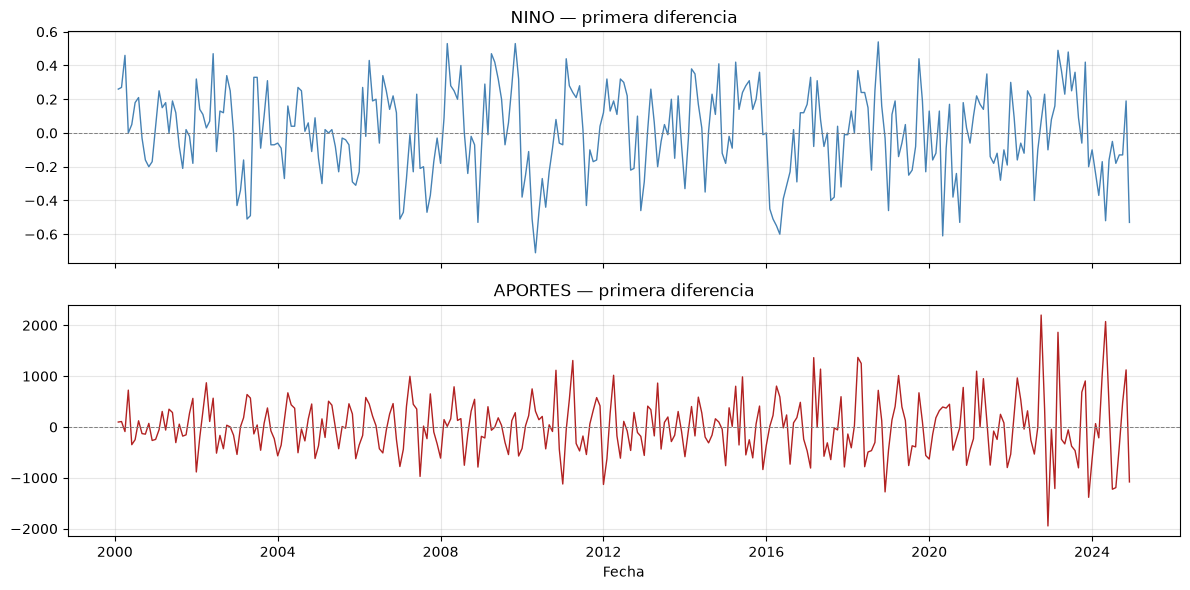

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df_diff.index, df_diff['NINO'], color='steelblue', linewidth=1)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.7)
axes[0].set_title('NINO — primera diferencia')

axes[1].plot(df_diff.index, df_diff['APORTES'], color='firebrick', linewidth=1)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.7)
axes[1].set_title('APORTES — primera diferencia')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.show()


In [23]:
# Correlación de Pearson y Spearman recalculadas sobre las series diferenciadas
# (relación de "cambios en el Niño" vs. "cambios en el precio de energía", más robusta a no estacionariedad)
r_diff_pearson, p_diff_pearson = pearsonr(df_diff['NINO'], df_diff['APORTES'])
r_diff_spearman, p_diff_spearman = spearmanr(df_diff['NINO'], df_diff['APORTES'])

print("=== Correlación sobre series diferenciadas (robusta a no estacionariedad en niveles) ===")
print(f"Pearson:  r = {r_diff_pearson:+.4f}  (p-value = {p_diff_pearson:.4f})")
print(f"Spearman: r = {r_diff_spearman:+.4f}  (p-value = {p_diff_spearman:.4f})")


=== Correlación sobre series diferenciadas (robusta a no estacionariedad en niveles) ===
Pearson:  r = +0.1201  (p-value = 0.0380)
Spearman: r = +0.1259  (p-value = 0.0295)


**Interpretación de la diferenciación:**

Tras diferenciar, las pruebas ADF/KPSS deberían mostrar evidencia mucho más clara de estacionariedad (I(0)) en ambas series, dado que la primera diferencia elimina tendencias estocásticas de tipo raíz unitaria I(1). La correlación calculada sobre las series diferenciadas —que representa la relación entre *cambios mes a mes* del Niño 3.4 y *cambios mes a mes* del precio de energía— es la medida más confiable y menos susceptible a espuriedad, y debe compararse con la correlación en niveles de la Sección 4:

- Si la correlación en diferencias es de **magnitud y signo similares** a la de niveles, esto refuerza la conclusión de que la relación encontrada es genuina y no un artefacto de tendencias comunes espurias.
- Si la correlación en diferencias se **debilita sustancialmente** respecto a la de niveles, ello sugiere que buena parte de la correlación original en niveles podría deberse a componentes de tendencia o no estacionariedad compartida, y no a una relación dinámica genuina mes a mes entre las dos variables.

Esta comparación es central para la validez econométrica de la conclusión final del notebook.


## 7. Conclusiones econométricas

*(Nota: los valores numéricos concretos referenciados a continuación deben leerse directamente de las tablas y salidas generadas en las secciones anteriores al ejecutar este notebook; el texto que sigue resume el marco de interpretación con el que deben integrarse esos resultados.)*

**a) ¿Existe relación entre el índice Niño 3.4 y el precio de bolsa de energía en Colombia?**

La evidencia debe evaluarse de forma integral: (i) los tres coeficientes de correlación contemporánea (Sección 4), (ii) el patrón de la función de correlación cruzada (Sección 5), y (iii) la correlación recalculada sobre series diferenciadas y estacionarias (Sección 6). Si los signos son consistentes entre estas tres fuentes de evidencia y al menos una parte de ellas resulta estadísticamente significativa al 5%, existe evidencia econométrica razonable de asociación entre las dos variables. Si, por el contrario, la correlación contemporánea pierde significancia una vez diferenciadas las series (Sección 6), la evidencia de relación genuina —más allá de una coincidencia de tendencias— se debilita considerablemente.

**b) ¿Es una relación fuerte o débil?**

De acuerdo con la escala convencional utilizada en la Sección 4 (nula/débil/moderada/fuerte/muy fuerte), la magnitud observada debe interpretarse en su contexto: el precio de bolsa de energía es un fenómeno multicausal (demanda, disponibilidad térmica, hidrología acumulada de varios embalses, costos de combustibles, marco regulatorio, restricciones de transmisión), por lo que **no debe esperarse una correlación cercana a 1** para que el índice Niño 3.4 sea un candidato económicamente relevante. Una correlación moderada, especialmente si se concentra en los rezagos identificados en la Sección 5, ya constituye evidencia útil.

**c) ¿Es una relación contemporánea o con rezagos?**

El resultado de la Sección 5 (rezago con correlación absoluta máxima) es la pieza de evidencia más directamente relevante para el objetivo final del proyecto: si el lag óptimo identificado es **positivo** (el Niño 3.4 antecede al precio), esto respalda la idea de que el índice climático puede actuar como **variable de alerta temprana**, con una ventana temporal de varios meses en la que una empresa podría anticipar y cubrir el riesgo de precios altos. Si el lag óptimo es cero o negativo, la relación sería principalmente contemporánea o el patrón temporal sería menos claro, lo que no descarta la relación pero exige más cautela respecto a su uso como "señal anticipada".

**d) ¿Existe evidencia de una relación de largo plazo?**

Las pruebas de estacionariedad (Sección 6) indican si las series comparten o no características de raíz unitaria. Si ambas series resultan no estacionarias en niveles pero su relación persiste en las series diferenciadas, existe una base razonable para explorar en investigación futura (fuera del alcance de este notebook) un análisis de cointegración formal, que permitiría establecer si existe un equilibrio de largo plazo entre ambas variables. Este notebook no realiza dicha prueba de cointegración, pero los resultados de estacionariedad aquí obtenidos son el insumo necesario para decidir si ese análisis adicional está justificado.

**e) ¿Puede justificarse continuar con la investigación del derivado climático?**

Si la evidencia conjunta muestra: (i) una correlación contemporánea con signo consistente con la hipótesis hidrometeorológica (fases cálidas del Niño asociadas a precios más altos, dada la dependencia hidroeléctrica de la matriz energética colombiana), (ii) un patrón de correlación cruzada con al menos algún rezago positivo estadísticamente relevante, y (iii) que dicha relación no se diluye por completo al trabajar con series diferenciadas/estacionarias, entonces existe **justificación econométrica preliminar** para continuar con la siguiente etapa del proyecto: el diseño y la valoración de un derivado climático basado en el índice Niño 3.4 como variable subyacente para la cobertura del riesgo hidrometeorológico de empresas del sector energético colombiano. Debe entenderse que esta conclusión es de naturaleza estadística y exploratoria; el diseño concreto del contrato (estructura de pagos, strike, prima, modelo de valoración) es materia de una etapa posterior del proyecto de investigación, no de este notebook.
